In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv(r'C:\Users\Janhavi\ChurnProject\data\processed\telco_clean.csv')
print("Loaded:", df.shape)
df.head()


Loaded: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# Lower tenure = newer customer = higher churn risk
# So we FLIP the scoring: low tenure gets score 4 (most at risk)
df['R_Score'] = pd.qcut(df['tenure'], q=4, labels=[4, 3, 2, 1])
df['R_Score'] = df['R_Score'].astype(int)

print(df[['tenure', 'R_Score']].head(10))


   tenure  R_Score
0       1        4
1      34        2
2       2        4
3      45        2
4       2        4
5       8        4
6      22        3
7      10        3
8      28        3
9      62        1


In [5]:
# Count how many add-on services each customer uses
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Convert Yes/No to 1/0
for col in service_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'No internet service': 0, 
                           'No phone service': 0})

df['Service_Count'] = df[service_cols].sum(axis=1)

# Score: more services = more engaged = score 4
df['F_Score'] = pd.qcut(df['Service_Count'], q=4, 
                         labels=[1, 2, 3, 4], duplicates='drop')
df['F_Score'] = df['F_Score'].astype(int)

print(df[['Service_Count', 'F_Score']].head(10))


   Service_Count  F_Score
0              1        1
1              3        2
2              3        2
3              3        2
4              1        1
5              5        3
6              4        3
7              1        1
8              6        4
9              3        2


In [7]:
# Higher total charges = more valuable customer = score 4
df['M_Score'] = pd.qcut(df['TotalCharges'], q=4, labels=[1, 2, 3, 4])
df['M_Score'] = df['M_Score'].astype(int)

print(df[['TotalCharges', 'M_Score']].head(10))


   TotalCharges  M_Score
0         29.85        1
1       1889.50        3
2        108.15        1
3       1840.75        3
4        151.65        1
5        820.50        2
6       1949.40        3
7        301.90        1
8       3046.05        3
9       3487.95        3


In [9]:
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

# Label each customer
def assign_segment(score):
    if score >= 9:
        return 'VIP'
    elif score >= 6:
        return 'Loyal'
    elif score >= 4:
        return 'At-Risk'
    else:
        return 'About to Churn'

df['Segment'] = df['RFM_Score'].apply(assign_segment)

print(df['Segment'].value_counts())


Segment
Loyal      4412
VIP        1929
At-Risk     691
Name: count, dtype: int64


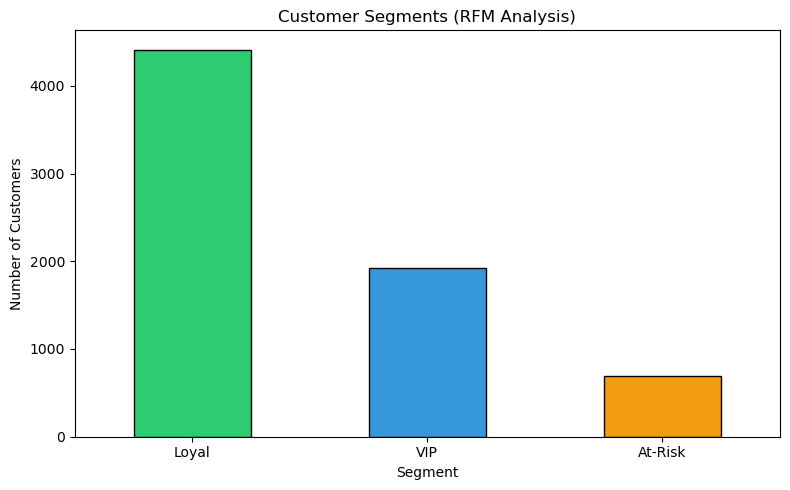

In [11]:
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
df['Segment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



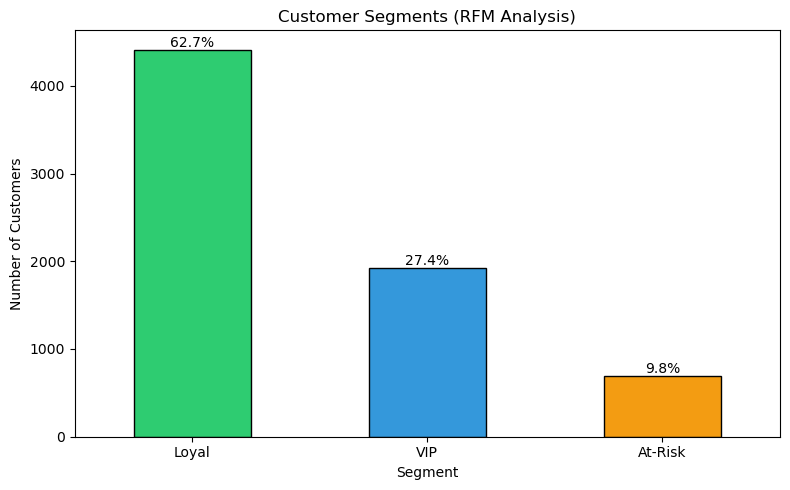

In [13]:
plt.figure(figsize=(8, 5))

# Get counts and percentages
counts = df['Segment'].value_counts()
total = len(df)
percentages = counts / total * 100

# Plot
ax = counts.plot(kind='bar',
                 color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
                 edgecolor='black')

# Add % labels
for i, value in enumerate(counts):
    percent = percentages.iloc[i]
    ax.text(i, value, f'{percent:.1f}%', ha='center', va='bottom')

plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
segment_summary = df.groupby('Segment').agg(
    Total_Customers=('Churn', 'count'),
    Churned=('Churn', 'sum'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean')
).round(2)

segment_summary['Churn_Rate_%'] = (
    segment_summary['Churned'] / segment_summary['Total_Customers'] * 100
).round(1)

print(segment_summary)


         Total_Customers  Churned  Avg_Monthly_Charges  Avg_Tenure  \
Segment                                                              
At-Risk              691       32                20.55       39.49   
Loyal               4412     1382                58.63       24.94   
VIP                 1929      455                94.76       47.01   

         Churn_Rate_%  
Segment                
At-Risk           4.6  
Loyal            31.3  
VIP              23.6  


## ⚠️ RFM Limitation — Subscription Data Insight

The traditional RFM model is not perfectly suited for subscription-based 
industries like telecom.

In this analysis, the segment labeled "Loyal" shows the highest churn rate (31.3%), 
which appears counterintuitive. This occurs because RFM scoring heavily weights 
spending and service usage, but does not fully capture customer lifecycle stage.

For example, newer customers who spend more and adopt multiple services may receive 
high RFM scores, yet they are often more likely to churn due to lack of long-term 
commitment.

**Key Takeaway:** RFM provides a useful baseline for segmentation, but it does not 
fully represent churn risk in subscription models. More accurate predictions require 
machine learning models that incorporate multiple features and interactions beyond 
RFM scores.

## ⚠️ RFM Limitation — Subscription Data Insight

The standard RFM model wasn't perfectly designed for subscription/telecom data.
In our results, 'Loyal' customers show the highest churn rate (31.3%) because 
they are medium-spend customers without long-term contracts — not truly "loyal" 
in behavior.

**Key Takeaway:** RFM gives us a useful starting segmentation, but for accurate 
churn prediction we need the Machine Learning model (Phase 5), which considers 
ALL features together, not just 3 scores.

This is why businesses use ML on top of RFM — not instead of it.


In [23]:
df.to_csv(r'C:\Users\Janhavi\ChurnProject\data\processed\telco_rfm.csv', index=False)
print("✅ RFM data saved!")


✅ RFM data saved!
